<a href="https://colab.research.google.com/github/iuryxavierr/iuryxavierr.github.io/blob/main/AJUSTAMENTO_B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TESTE COM RANDOM FOREST REGRESSION 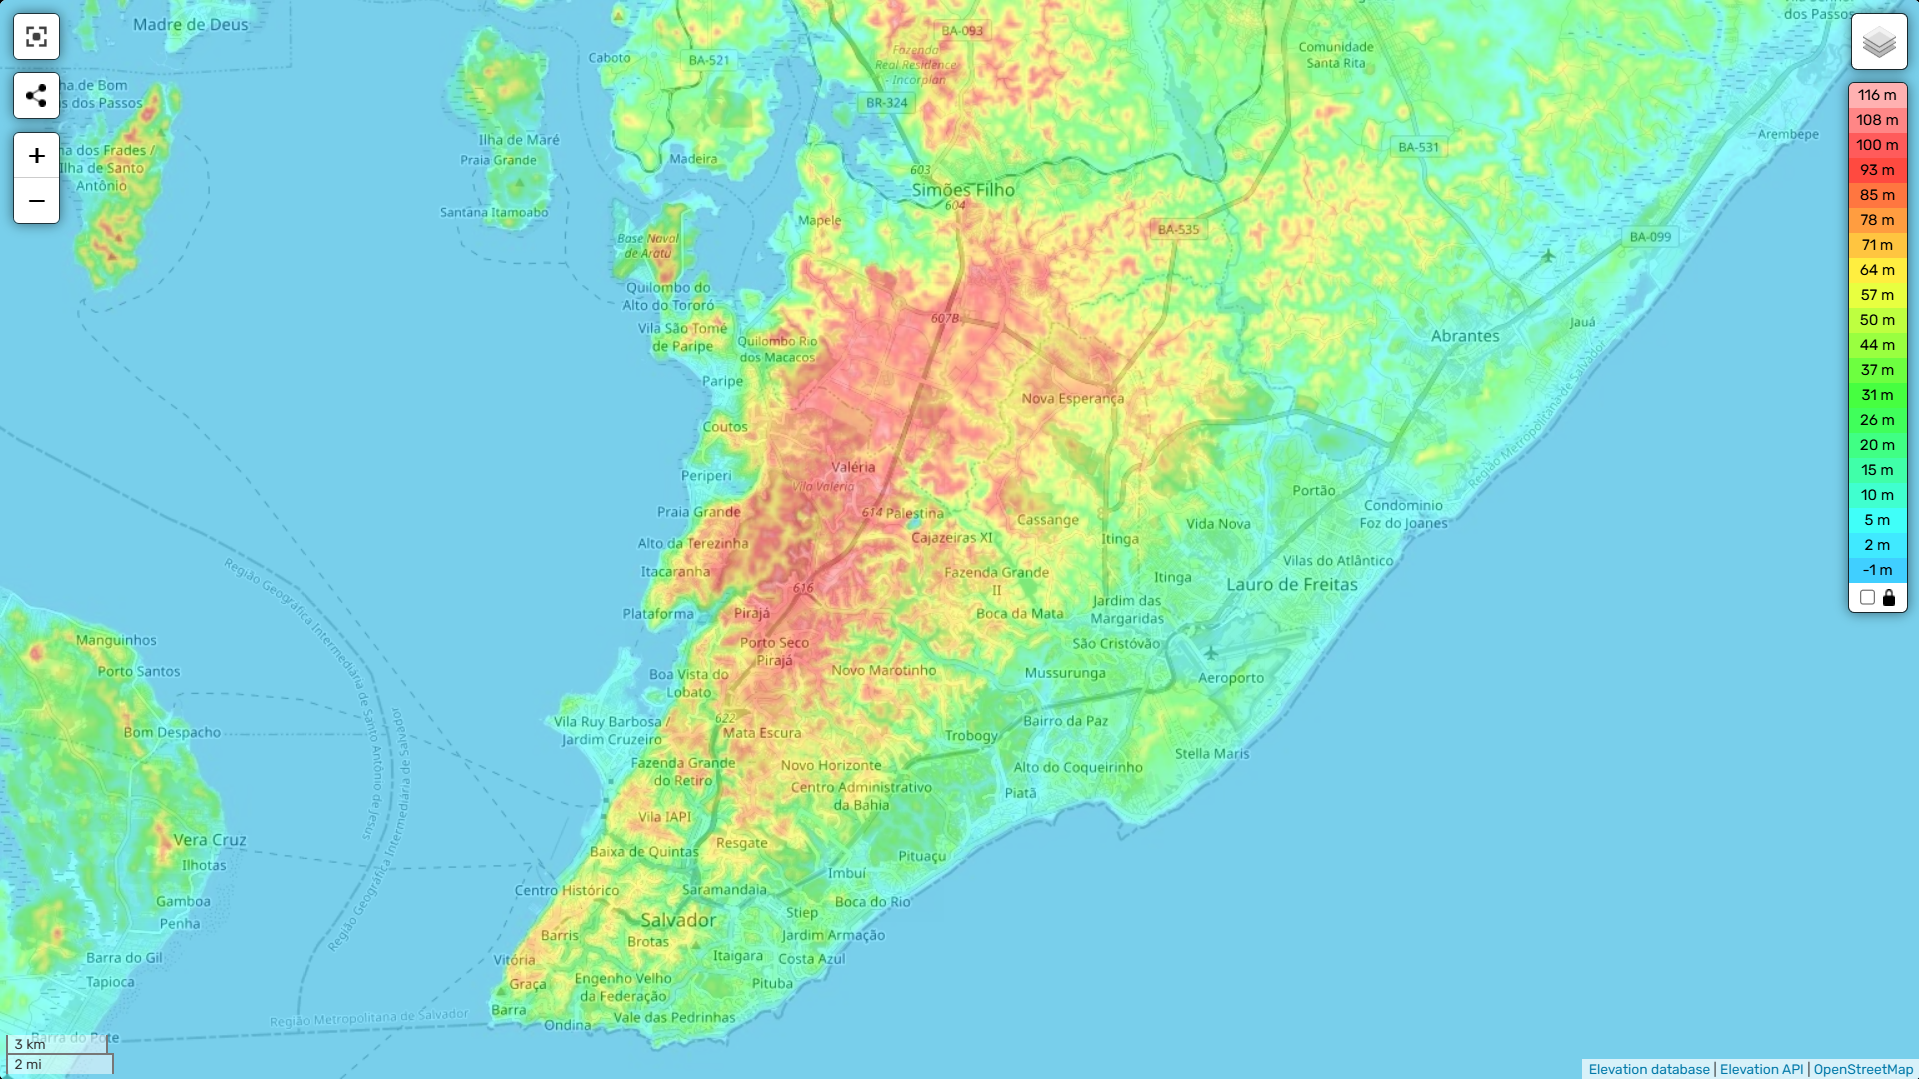**


In [1]:
# ==============================================================================
# CÉLULA 1: CARREGAMENTO DOS DADOS
# ==============================================================================
from google.colab import files
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import io

print("--- Passo 1: Carregando os dados de treino ---")
print("Por favor, clique no botão 'Escolher arquivos' abaixo e suba o 'Modelo_Geoidal.csv':")

uploaded = files.upload()

if not uploaded:
    print("❌ Nenhum arquivo foi enviado. Por favor, rode a célula novamente e selecione o arquivo.")
else:
    # Pega o nome do primeiro arquivo carregado automaticamente
    nome_treino = list(uploaded.keys())[0]
    print(f"\n✅ Arquivo '{nome_treino}' carregado com sucesso!")

    # Leitura dos dados
    df_treino = pd.read_csv(io.BytesIO(uploaded[nome_treino]), sep=';')

    # Ajuste de dados (trocando ',' por '.' se necessário)
    # Convertemos para string primeiro para garantir que o replace funcione
    X_treino = pd.to_numeric(df_treino.iloc[:, 1].astype(str).str.replace(',', '.'), errors='coerce').values
    Y_treino = pd.to_numeric(df_treino.iloc[:, 2].astype(str).str.replace(',', '.'), errors='coerce').values
    h_treino = pd.to_numeric(df_treino.iloc[:, 3].astype(str).str.replace(',', '.'), errors='coerce').values
    H_treino = pd.to_numeric(df_treino.iloc[:, 4].astype(str).str.replace(',', '.'), errors='coerce').values

    # Limpeza básica (remover linhas que deram erro na conversão)
    mascara = ~np.isnan(X_treino) & ~np.isnan(Y_treino) & ~np.isnan(h_treino) & ~np.isnan(H_treino)
    X_treino, Y_treino, h_treino, H_treino = X_treino[mascara], Y_treino[mascara], h_treino[mascara], H_treino[mascara]

    # Cálculo do Alvo (Z)
    Z_treino = h_treino - H_treino
    features_treino = np.stack([X_treino, Y_treino], axis=1)

    # Treino da IA (Random Forest)
    modelo_rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    modelo_rf.fit(features_treino, Z_treino)

    print(f"✅ {len(Z_treino)} pontos processados.")

--- Passo 1: Carregando os dados de treino ---
Por favor, clique no botão 'Escolher arquivos' abaixo e suba o 'Modelo_Geoidal.csv':


Saving Modelo_Geoidal.csv to Modelo_Geoidal.csv

✅ Arquivo 'Modelo_Geoidal.csv' carregado com sucesso!
✅ 153 pontos processados.


In [3]:
modelo_rf.score(features_treino, Z_treino)

0.9739238313600086

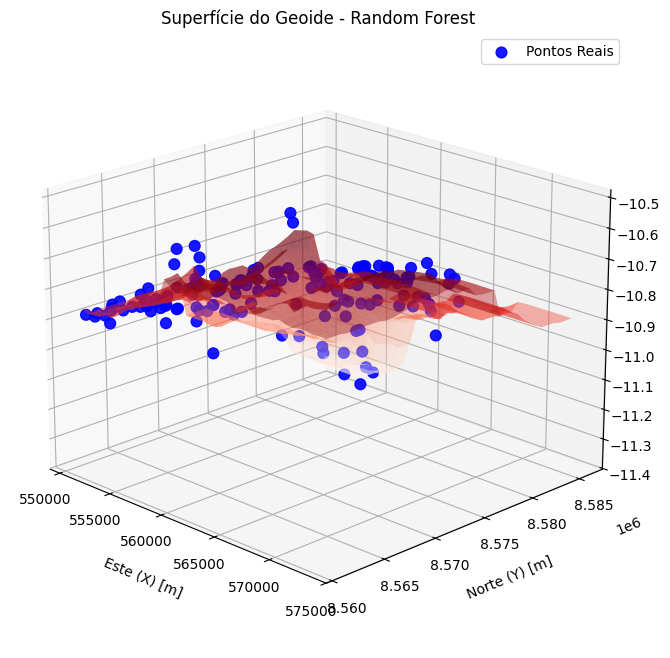

In [ ]:
# ==============================================================================
# CÉLULA 2: VISUALIZAÇÃO TRIDIMENSIONAL DA I.A.
# ==============================================================================
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x_malha = np.linspace(X_treino.min(), X_treino.max(), 40)
y_malha = np.linspace(Y_treino.min(), Y_treino.max(), 40)
X_grid, Y_grid = np.meshgrid(x_malha, y_malha)

pontos_malha = np.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
Z_superficie_rf = modelo_rf.predict(pontos_malha).reshape(X_grid.shape)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_treino, Y_treino, Z_treino, color='blue', s=60, alpha=0.9, label='Pontos Reais')
ax.plot_surface(X_grid, Y_grid, Z_superficie_rf, cmap='Reds', alpha=0.4, edgecolor='none')

ax.set_xlabel('Este (X) [m]', labelpad=10)
ax.set_ylabel('Norte (Y) [m]', labelpad=10)
ax.set_zlabel('Ondulação Geoidal (Z) [m]', labelpad=10)
ax.set_title('Superfície do Geoide - Random Forest')

ax.legend()
ax.view_init(elev=20, azim=-45)
plt.show()

In [ ]:
# ==============================================================================
# CÉLULA 3: IMPORTAÇÃO DOS DADOS DO PROFESSOR PARA VALIDAÇÃO
# ==============================================================================
print("👇 Faça o upload do arquivo CSV com os dados do PROFESSOR (Verificação):")
arquivo_prof = files.upload()
nome_prof = list(arquivo_prof.keys())[0]

df_prof = pd.read_csv(io.BytesIO(arquivo_prof[nome_prof]), sep=';')

# Extraindo as variáveis para o teste
IDs = df_prof.iloc[:, 0].values
X_prof = pd.to_numeric(df_prof.iloc[:, 1].astype(str).str.replace(',', '.'), errors='coerce').values
Y_prof = pd.to_numeric(df_prof.iloc[:, 2].astype(str).str.replace(',', '.'), errors='coerce').values
h_prof = pd.to_numeric(df_prof.iloc[:, 3].astype(str).str.replace(',', '.'), errors='coerce').values
H_prof = pd.to_numeric(df_prof.iloc[:, 4].astype(str).str.replace(',', '.'), errors='coerce').values

Z_real_prof = h_prof - H_prof
features_prof = np.stack([X_prof, Y_prof], axis=1)

print(f"\n✅ Arquivo '{nome_prof}' carregado! Pronto para o comparativo.")

👇 Faça o upload do arquivo CSV com os dados do PROFESSOR (Verificação):


Saving Modelo_Geoidal_verificacao.csv to Modelo_Geoidal_verificacao.csv

✅ Arquivo 'Modelo_Geoidal_verificacao.csv' carregado! Pronto para o comparativo.


In [ ]:
# ==============================================================================
# CÉLULA 4: AVALIAÇÃO FINAL - MÉTODO CLÁSSICO VS MACHINE LEARNING
# ==============================================================================
from sklearn.linear_model import LinearRegression

# 1. Calculando o Método Clássico (Regressão Linear do Professor)
modelo_linear = LinearRegression()
modelo_linear.fit(features_treino, Z_treino) # Treina na mesma base que a IA
Z_pred_linear = modelo_linear.predict(features_prof)
erros_linear = Z_pred_linear - Z_real_prof

# 2. Calculando o Método de Inteligência Artificial
Z_pred_rf = modelo_rf.predict(features_prof)
erros_rf = Z_pred_rf - Z_real_prof

# --- EXIBINDO OS ERROS PONTO A PONTO ---
print("="*65)
print(" RESÍDUOS PONTO A PONTO (ERRO EM METROS)")
print("="*65)
print(f"{'Estação':<12} | {'Prof (Reg. Linear)':<20} | {'I.A. (Random Forest)'}")
print("-" * 65)
for i in range(len(IDs)):
    print(f"{IDs[i]:<12} | {erros_linear[i]:>17.6f} m | {erros_rf[i]:>15.6f} m")

# --- CALCULANDO MÉDIA, RMS E MELHORIA ---
rms_linear = erros_linear.std()
erro_medio_linear = erros_linear.mean()

rms_rf = erros_rf.std()
erro_medio_rf = erros_rf.mean()

melhoria_rms = ((rms_linear - rms_rf) / rms_linear) * 100

tabela_final = pd.DataFrame({
    'Métrica Estatística': ['Erro Médio (m)', 'RMS (m)'],
    'Prof (Reg. Linear)': [f"{erro_medio_linear:.6f}", f"{rms_linear:.6f}"],
    'I.A. (Random Forest)': [f"{erro_medio_rf:.6f}", f"{rms_rf:.6f}"]
})

# --- EXIBINDO A TABELA FINAL ---
print("\n" + "="*75)
print("              QUADRO COMPARATIVO FINAL")
print("="*75)
print(tabela_final.to_string(index=False))
print("-" * 75)

if melhoria_rms > 0:
    print(f"🎯 Conclusão: A IA superou o método tradicional, reduzindo o erro em {melhoria_rms:.2f}%!")
else:
    print(f"🎯 Conclusão: O método tradicional se manteve firme para esta geometria específica.")
print("="*75)

 RESÍDUOS PONTO A PONTO (ERRO EM METROS)
Estação      | Prof (Reg. Linear)   | I.A. (Random Forest)
-----------------------------------------------------------------
MR00039      |          0.031048 m |       -0.041325 m
MR00118      |         -0.056431 m |       -0.033255 m
MR00119      |         -0.033766 m |       -0.017945 m
MR208AZ      |         -0.015787 m |       -0.033748 m
MR208SSA     |         -0.002945 m |       -0.025268 m
MR227SSA     |         -0.033491 m |       -0.054580 m
MR238SSA     |          0.194816 m |        0.069130 m
MR244SSA     |         -0.036093 m |       -0.059220 m
MR262SSA     |          0.015567 m |        0.033168 m
MR275AZ      |          0.035802 m |       -0.003324 m
MR275SSA     |          0.065260 m |       -0.002811 m
MR277SSA     |          0.097442 m |       -0.009761 m
MR278AZ      |          0.101751 m |        0.020333 m
MR287AZ      |         -0.012788 m |       -0.010743 m
RN00138      |         -0.091305 m |       -0.126353 m
RN00148  